<a href="https://colab.research.google.com/github/ankit-rathi/quantvesting_v3/blob/main/notebooks/quantvesting_backtest_end_to_end_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantvesting — Strategy Prototype

### A simple, user-friendly end-to-end backtest

This notebook answers one question:

> **Does the Quantvesting strategy behave sensibly when we run it on real historical prices?**

It uses six NSE-listed securities through `yfinance`.

**Prototype assumptions**
- Market data: approximate Yahoo Finance data
- Corporate actions: ignored for now
- Signals: read from a small CSV you provide
- Backtest: daily data, EOD decision → next trading-day open entry
- This is a demonstration of the strategy mechanics, **not investment advice or production performance evidence**

---

## Your only input

Create this file next to the notebook:

`data/signals.csv`

Example:

```text
symbol,conviction
RELIANCE,X-LC
TCS,X-LC
INFY,X-LC
ITC,H-LC
HDFCBANK,H-LC
HINDALCO,H-LC
```

The notebook will automatically:
1. validate the file,
2. download the six stocks,
3. calculate running ATH and ATH Gap,
4. apply your conviction classification,
5. run the portfolio,
6. show the results in a presentation-friendly dashboard.


In [1]:
# 1. Setup
import sys, subprocess, importlib.util, warnings, math
from pathlib import Path

if importlib.util.find_spec("yfinance") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "yfinance"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import yfinance as yf

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

DATA_DIR = Path("sample_data")
SIGNAL_FILE = DATA_DIR / "signals.csv"

START_DATE = "2021-10-01"
END_DATE = "2026-09-01"

INITIAL_CAPITAL = 10_000_000       # ₹1 crore
ENTRY_ATH_GAP = 0.20
MAX_HOLDINGS = 5
TRANSACTION_COST_BPS = 10
SLIPPAGE_BPS = 5

print("✓ Environment ready")


✓ Environment ready


In [2]:
# 2. Load and validate YOUR signal file
if not SIGNAL_FILE.exists():
    raise FileNotFoundError(
        f"Missing {SIGNAL_FILE}. Create it with columns: symbol,conviction"
    )

signals_config = pd.read_csv(SIGNAL_FILE)
signals_config.columns = [str(c).strip().lower() for c in signals_config.columns]

required = {"symbol", "conviction"}
missing = required - set(signals_config.columns)
if missing:
    raise ValueError(f"signals.csv is missing columns: {sorted(missing)}")

signals_config["symbol"] = signals_config["symbol"].astype(str).str.strip().str.upper()
signals_config["conviction"] = signals_config["conviction"].astype(str).str.strip().str.upper()

allowed = {"X-LC", "H-LC"}
bad = sorted(set(signals_config["conviction"]) - allowed)
if bad:
    raise ValueError(f"Unsupported conviction values: {bad}. Use X-LC or H-LC.")

if signals_config["symbol"].duplicated().any():
    dupes = signals_config.loc[signals_config["symbol"].duplicated(), "symbol"].tolist()
    raise ValueError(f"Duplicate symbols in signals.csv: {dupes}")

#if len(signals_config) != 6:
#    raise ValueError(f"Expected 6 securities, found {len(signals_config)}.")

YF_TICKERS = {f"{s}.NS": s for s in signals_config["symbol"]}

print("✓ Signal file loaded")
print()
display(signals_config.style.hide(axis="index"))


✓ Signal file loaded



symbol,conviction
BSE,X-LC
BAJAJ-AUTO,X-LC
HDFCAMC,X-LC
M&M,X-LC
HEROMOTOCO,H-LC
BHARTIARTL,H-LC
SIEMENS,H-LC
BOSCHLTD,X-LC
ADANIPORTS,X-LC
TORNTPHARM,H-LC


## 1. Your strategy universe

The CSV above is deliberately kept separate from market data.

That means later we can replace the CSV with the **real historical Quantvesting signal snapshots** without changing the backtest engine.

For this prototype, the six classifications are treated as the user's supplied strategy universe.


In [3]:
# 3. Download market data
raw = yf.download(
    list(YF_TICKERS.keys()),
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=False,
    actions=False,
    progress=False,
    repair=True,
    group_by="column",
)

if raw is None or raw.empty:
    raise RuntimeError("No market data returned by yfinance.")

frames = []
for yf_ticker, symbol in YF_TICKERS.items():
    if isinstance(raw.columns, pd.MultiIndex):
        if yf_ticker in raw.columns.get_level_values(-1):
            sub = raw.xs(yf_ticker, axis=1, level=-1, drop_level=True).copy()
        elif yf_ticker in raw.columns.get_level_values(0):
            sub = raw.xs(yf_ticker, axis=1, level=0, drop_level=True).copy()
        else:
            continue
    else:
        sub = raw.copy()

    sub = sub.rename(columns={c: str(c).title() for c in sub.columns})
    needed = ["Open", "High", "Low", "Close", "Volume"]
    missing_cols = [c for c in needed if c not in sub.columns]
    if missing_cols:
        raise ValueError(f"{symbol}: missing {missing_cols}")

    sub = sub[needed].copy()
    sub["date"] = pd.to_datetime(sub.index).tz_localize(None)
    sub["symbol"] = symbol
    frames.append(sub.reset_index(drop=True))

prices = pd.concat(frames, ignore_index=True)
prices = prices[["date","symbol","Open","High","Low","Close","Volume"]]
prices = prices.sort_values(["symbol","date"]).reset_index(drop=True)

print(f"✓ Downloaded {len(prices):,} daily observations")
print(f"  {prices['date'].min():%d %b %Y} → {prices['date'].max():%d %b %Y}")


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: LTIM.NS"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['LTIM.NS']: YFTzMissingError('possibly delisted; no timezone found')


✓ Downloaded 64,554 daily observations
  01 Oct 2021 → 31 Aug 2026


In [4]:
# 4. Data health — compact user-facing check
quality = {
    "Duplicate rows": int(prices.duplicated(["symbol","date"]).sum()),
    "Missing prices": int(prices[["Open","High","Low","Close"]].isna().any(axis=1).sum()),
    "Non-positive prices": int((prices[["Open","High","Low","Close"]] <= 0).any(axis=1).sum()),
    "Invalid OHLC rows": int((
        (prices["Low"] > prices["Open"]) |
        (prices["Low"] > prices["Close"]) |
        (prices["Low"] > prices["High"]) |
        (prices["High"] < prices["Open"]) |
        (prices["High"] < prices["Close"])
    ).sum())
}

quality_df = pd.DataFrame(
    [{"Check": k, "Issues": v, "Status": "✓ OK" if v == 0 else "⚠ Review"} for k,v in quality.items()]
)

display(quality_df.style.hide(axis="index"))


Check,Issues,Status
Duplicate rows,0,✓ OK
Missing prices,2595,⚠ Review
Non-positive prices,0,✓ OK
Invalid OHLC rows,0,✓ OK


## 2. The key strategy signal

For every stock and every day we calculate:

**ATH Gap = (Running ATH − Current Close) / Current Close**

Example:

- Running ATH = ₹1,000
- Current price = ₹800
- ATH Gap = 25%

So the stock has **25% upside to its running ATH**.

The strategy looks for conviction (`X-LC` or `H-LC`) **and** sufficient ATH Gap.


In [5]:
prices["running_ath"] = prices.groupby("symbol")["High"].cummax()
prices["ath_gap"] = (prices["running_ath"] - prices["Close"]) / prices["Close"]

conviction_map = dict(zip(signals_config["symbol"], signals_config["conviction"]))
prices["conviction"] = prices["symbol"].map(conviction_map)

# Map conviction to a numerical rank for sorting candidates
conviction_rank_map = {
    "X-LC": 1, # Assign lower rank for higher priority / conviction
    "H-LC": 2,
}
prices["rank"] = prices["conviction"].map(conviction_rank_map)

prices["next_date"] = prices.groupby("symbol")["date"].shift(-1)
prices["next_open"] = prices.groupby("symbol")["Open"].shift(-1)

latest = (
    prices.sort_values("date")
    .groupby("symbol")
    .tail(1)[["symbol","date","Close","running_ath","ath_gap","conviction"]]
    .sort_values("ath_gap", ascending=False)
)

latest_display = latest.copy()
latest_display["date"] = latest_display["date"].dt.strftime("%d %b %Y")
latest_display["Close"] = latest_display["Close"].map(lambda x: f"₹{x:,.2f}")
latest_display["running_ath"] = latest_display["running_ath"].map(lambda x: f"₹{x:,.2f}")
latest_display["ath_gap"] = latest_display["ath_gap"].map(lambda x: f"{x:.1%}")

display(latest_display.style.hide(axis="index"))

symbol,date,Close,running_ath,ath_gap,conviction
TMPV,31 Aug 2026,₹308.85,"₹1,179.00",281.7%,X-LC
ITC,31 Aug 2026,₹255.50,₹508.90,99.2%,X-LC
TCS,31 Aug 2026,"₹2,399.30","₹4,592.25",91.4%,X-LC
INFY,31 Aug 2026,"₹1,133.80","₹2,006.45",77.0%,X-LC
GODREJCP,31 Aug 2026,₹901.30,"₹1,541.85",71.1%,X-LC
VBL,31 Aug 2026,₹400.45,₹681.12,70.1%,X-LC
JIOFIN,31 Aug 2026,₹241.35,₹394.70,63.5%,X-LC
HINDUNILVR,31 Aug 2026,"₹1,967.40","₹3,035.00",54.3%,X-LC
HCLTECH,31 Aug 2026,"₹1,312.20","₹2,012.20",53.3%,X-LC
DMART,31 Aug 2026,"₹3,900.00","₹5,900.00",51.3%,X-LC


## 3. Backtest engine

### Event order

**End of day T**
→ calculate today's signal  
→ freeze today's running ATH  
→ select candidates

**Next trading day T+1**
→ buy at the opening price

While holding:
→ if today's High reaches the **frozen entry ATH**, exit

This separation is important: the strategy never gets to see tomorrow's open when making today's decision.


In [6]:
# 6. Backtest engine
def run_backtest(prices, initial_capital=INITIAL_CAPITAL):
    df = prices.sort_values(["date","symbol"]).copy()
    dates = sorted(df["date"].unique())

    cash = float(initial_capital)
    positions = {}
    pending_entries = {}
    trades = []
    daily = []

    cost_rate = TRANSACTION_COST_BPS / 10_000
    slip_rate = SLIPPAGE_BPS / 10_000

    for date in dates:
        day = df[df["date"] == date].set_index("symbol")

        # A) Execute yesterday's EOD decisions at today's open
        scheduled = sorted(
            pending_entries.pop(date, []),
            key=lambda x: (x["rank"], x["symbol"])
        )

        for sig in scheduled:
            symbol = sig["symbol"]

            if symbol in positions or symbol not in day.index:
                continue
            if len(positions) >= MAX_HOLDINGS:
                continue

            open_px = float(day.loc[symbol, "Open"])
            if not np.isfinite(open_px) or open_px <= 0:
                continue

            slots = max(1, MAX_HOLDINGS - len(positions))
            target_notional = cash / slots
            entry_px = open_px * (1 + slip_rate)

            shares = math.floor(target_notional / (entry_px * (1 + cost_rate)))
            if shares <= 0:
                continue

            notional = shares * entry_px
            cost = notional * cost_rate

            if notional + cost > cash:
                shares = math.floor(cash / (entry_px * (1 + cost_rate)))
                notional = shares * entry_px
                cost = notional * cost_rate

            if shares <= 0:
                continue

            cash -= notional + cost

            positions[symbol] = {
                "entry_date": date,
                "signal_date": sig["signal_date"],
                "entry_price": entry_px,
                "shares": shares,
                "entry_ath": sig["signal_ath"],
                "conviction": sig["conviction"],
                "rank": sig["rank"],
            }

            trades.append({
                "date": date,
                "event": "ENTRY",
                "symbol": symbol,
                "price": entry_px,
                "shares": shares,
                "notional": notional,
                "cost": cost,
                "reason": "EOD signal → T+1 open",
                "signal_date": sig["signal_date"],
                "entry_ath": sig["signal_ath"],
                "conviction": sig["conviction"],
                "rank": sig["rank"],
            })

        # B) Check frozen ATH exits
        for symbol in list(positions):
            if symbol not in day.index:
                continue

            pos = positions[symbol]
            high_px = float(day.loc[symbol, "High"])

            if high_px >= pos["entry_ath"]:
                exit_px = pos["entry_ath"] * (1 - slip_rate)
                notional = pos["shares"] * exit_px
                cost = notional * cost_rate
                cash += notional - cost

                trades.append({
                    "date": date,
                    "event": "EXIT",
                    "symbol": symbol,
                    "price": exit_px,
                    "shares": pos["shares"],
                    "notional": notional,
                    "cost": cost,
                    "reason": "Frozen entry ATH reached",
                    "signal_date": pos["signal_date"],
                    "entry_ath": pos["entry_ath"],
                    "conviction": pos["conviction"],
                    "rank": pos["rank"],
                })
                del positions[symbol]

        # C) Today's EOD signal → schedule tomorrow's entry
        slots = MAX_HOLDINGS - len(positions)

        if slots > 0:
            candidates = (
                df[
                    (df["date"] == date) &
                    (df["conviction"].isin(["X-LC","H-LC"])) &
                    (df["ath_gap"] >= ENTRY_ATH_GAP) &
                    (~df["symbol"].isin(positions.keys()))
                ]
                .sort_values(["rank","symbol"])
                .head(slots)
            )

            for _, row in candidates.iterrows():
                if pd.isna(row["next_date"]):
                    continue

                pending_entries.setdefault(row["next_date"], []).append({
                    "symbol": row["symbol"],
                    "signal_date": date,
                    "signal_ath": float(row["running_ath"]),
                    "conviction": row["conviction"],
                    "rank": int(row["rank"]),
                })

        # D) Mark portfolio to market
        invested = 0.0
        for symbol, pos in positions.items():
            if symbol in day.index:
                invested += pos["shares"] * float(day.loc[symbol, "Close"])

        daily.append({
            "date": date,
            "cash": cash,
            "invested_value": invested,
            "portfolio_value": cash + invested,
            "open_positions": len(positions),
        })

    return pd.DataFrame(daily), pd.DataFrame(trades)

portfolio, trades = run_backtest(prices)

print(f"✓ Backtest completed: {len(portfolio):,} trading days")
print(f"✓ Trade events generated: {len(trades):,}")


✓ Backtest completed: 1,218 trading days
✓ Trade events generated: 35


In [7]:
# 7. User-friendly headline results
portfolio["peak"] = portfolio["portfolio_value"].cummax()
portfolio["drawdown"] = portfolio["portfolio_value"] / portfolio["peak"] - 1

ending = float(portfolio["portfolio_value"].iloc[-1])
total_return = ending / INITIAL_CAPITAL - 1
years = (portfolio["date"].iloc[-1] - portfolio["date"].iloc[0]).days / 365.25
cagr = (ending / INITIAL_CAPITAL) ** (1 / years) - 1 if years > 0 else np.nan
max_dd = float(portfolio["drawdown"].min())

entries = trades[trades["event"] == "ENTRY"].copy() if not trades.empty else pd.DataFrame()
exits = trades[trades["event"] == "EXIT"].copy() if not trades.empty else pd.DataFrame()

# KPI cards as a clean table rather than raw Series output.
kpis = pd.DataFrame([[
    f"₹{INITIAL_CAPITAL/1e7:.1f} Cr",
    f"₹{ending/1e7:.2f} Cr",
    f"{total_return:.1%}",
    f"{cagr:.1%}",
    f"{max_dd:.1%}",
    f"{len(entries)}",
    f"{len(exits)}",
]], columns=[
    "Starting Capital","Ending Value","Total Return","CAGR",
    "Max Drawdown","Entries","Exits"
])

display(kpis.style
        .hide(axis="index")
        .set_properties(**{"font-size":"14pt","font-weight":"bold","text-align":"center"})
        .set_table_styles([
            {"selector":"th","props":[("text-align","center"),("font-size","11pt")]},
            {"selector":"td","props":[("padding","12px"),("text-align","center")]}
        ]))


Starting Capital,Ending Value,Total Return,CAGR,Max Drawdown,Entries,Exits
₹1.0 Cr,₹1.97 Cr,96.7%,14.8%,-24.5%,20,15


# 4. The result

The chart below is the main user-facing output.

It answers:

> **If ₹1 crore had followed these rules over the selected historical period, how did the portfolio value evolve?**

The return number alone is not enough. The shape of the curve and the drawdowns matter too.


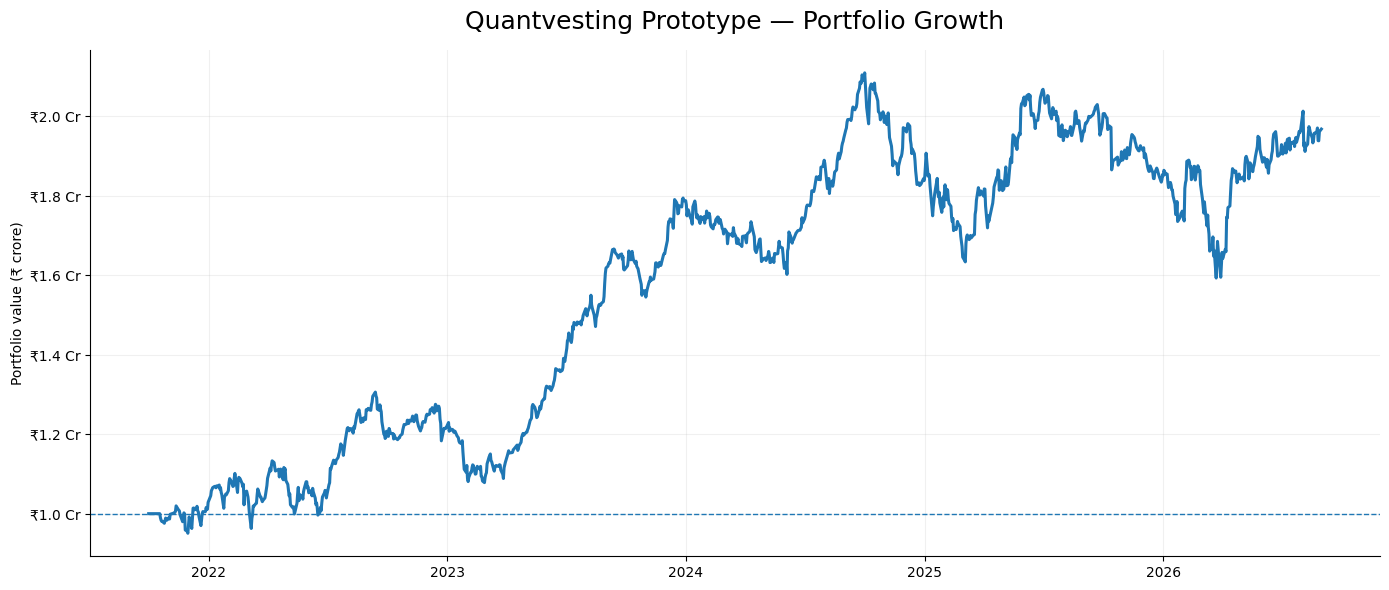

In [8]:
# 8. Portfolio growth — presentation chart
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(portfolio["date"], portfolio["portfolio_value"] / 1e7, linewidth=2.2)

ax.axhline(INITIAL_CAPITAL / 1e7, linestyle="--", linewidth=1)
ax.set_title("Quantvesting Prototype — Portfolio Growth", fontsize=18, pad=15)
ax.set_ylabel("Portfolio value (₹ crore)")
ax.set_xlabel("")
ax.grid(alpha=0.18)
ax.spines[["top","right"]].set_visible(False)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"₹{x:.1f} Cr"))
fig.tight_layout()
plt.show()


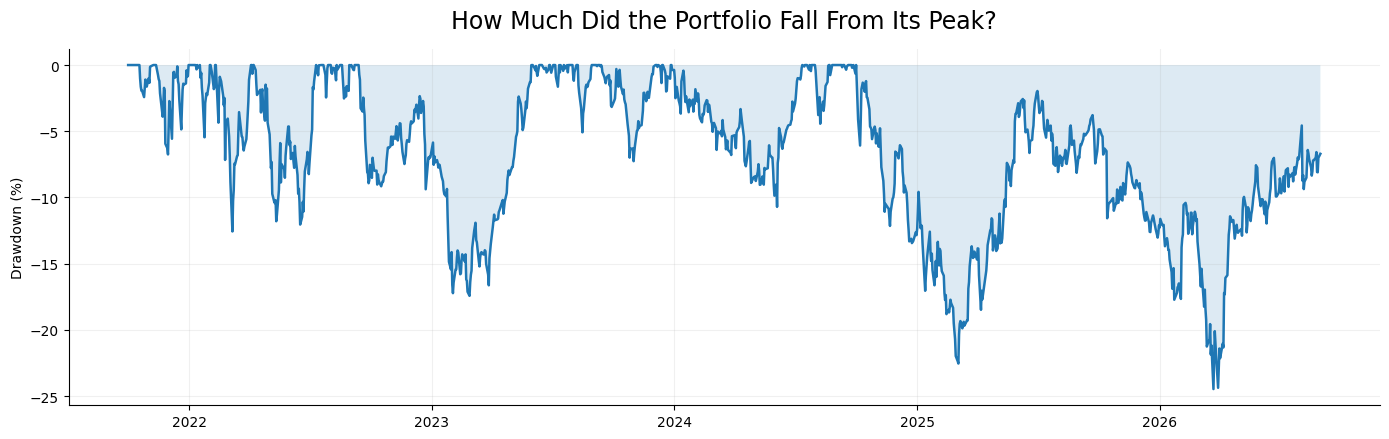

In [9]:
# 9. Drawdown — presentation chart
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(portfolio["date"], portfolio["drawdown"] * 100, linewidth=1.8)
ax.fill_between(portfolio["date"], portfolio["drawdown"] * 100, 0, alpha=0.15)

ax.set_title("How Much Did the Portfolio Fall From Its Peak?", fontsize=17, pad=15)
ax.set_ylabel("Drawdown (%)")
ax.set_xlabel("")
ax.grid(alpha=0.18)
ax.spines[["top","right"]].set_visible(False)

fig.tight_layout()
plt.show()


# 5. What the strategy actually did

The next view is intentionally about **behaviour**, not just performance.

Each dot represents an entry. This makes it easy to answer questions such as:

- Which stocks generated entries?
- How frequently did the strategy rotate?
- Were positions held for a few days or months?
- Are exits happening at the frozen ATH as intended?


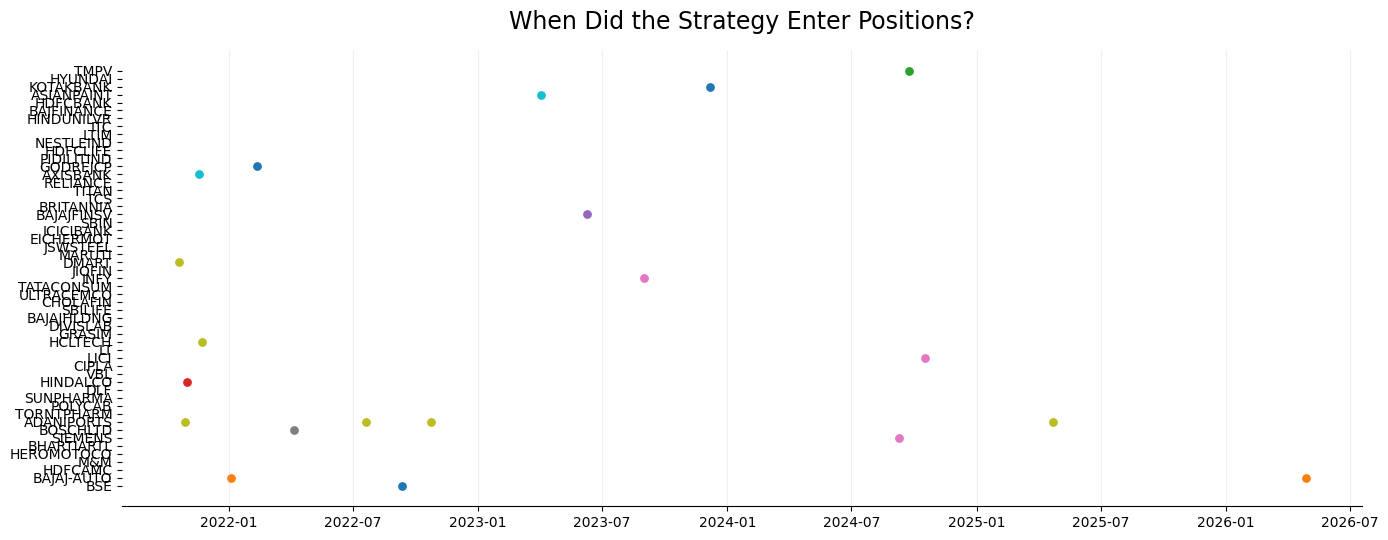

In [10]:
# 10. Entry / exit activity
if trades.empty:
    print("No trades were generated.")
else:
    events = trades.copy()
    events["date"] = pd.to_datetime(events["date"])

    symbols = list(TICKERS.values()) if "TICKERS" in globals() else list(signals_config["symbol"])
    symbol_order = {s:i for i,s in enumerate(symbols)}

    fig, ax = plt.subplots(figsize=(14, 5.5))

    for symbol in symbols:
        e = events[(events["symbol"] == symbol) & (events["event"] == "ENTRY")]
        x = e["date"]
        y = [symbol_order[symbol]] * len(e)
        ax.scatter(x, y, s=28, label=symbol)

    ax.set_yticks(range(len(symbols)))
    ax.set_yticklabels(symbols)
    ax.set_title("When Did the Strategy Enter Positions?", fontsize=17, pad=15)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.18)
    ax.spines[["top","right","left"]].set_visible(False)

    fig.tight_layout()
    plt.show()


In [11]:
# 11. Trade ledger — clean inspection table
if trades.empty:
    print("No trades.")
else:
    ledger = trades.sort_values(["date","event","symbol"]).copy()
    ledger["date"] = pd.to_datetime(ledger["date"]).dt.strftime("%d %b %Y")
    ledger["signal_date"] = pd.to_datetime(ledger["signal_date"]).dt.strftime("%d %b %Y")
    ledger["price"] = ledger["price"].map(lambda x: f"₹{x:,.2f}")
    ledger["notional"] = ledger["notional"].map(lambda x: f"₹{x:,.0f}")
    ledger["cost"] = ledger["cost"].map(lambda x: f"₹{x:,.0f}")
    ledger = ledger[[
        "date","event","symbol","conviction","rank",
        "price","shares","notional","reason","signal_date","entry_ath"
    ]]
    ledger["entry_ath"] = ledger["entry_ath"].map(lambda x: f"₹{x:,.2f}")

    display(ledger.style.hide(axis="index"))


date,event,symbol,conviction,rank,price,shares,notional,reason,signal_date,entry_ath
19 Oct 2021,ENTRY,DMART,X-LC,1,"₹5,002.50",399,"₹1,995,998",EOD signal → T+1 open,18 Oct 2021,"₹5,900.00"
29 Oct 2021,ENTRY,ADANIPORTS,X-LC,1,₹697.35,2865,"₹1,997,903",EOD signal → T+1 open,28 Oct 2021,₹829.90
01 Nov 2021,ENTRY,HINDALCO,H-LC,2,₹464.03,4307,"₹1,998,585",EOD signal → T+1 open,29 Oct 2021,₹551.85
18 Nov 2021,ENTRY,AXISBANK,X-LC,1,₹715.36,2794,"₹1,998,709",EOD signal → T+1 open,17 Nov 2021,₹866.90
23 Nov 2021,ENTRY,HCLTECH,X-LC,1,"₹1,105.55",1807,"₹1,997,733",EOD signal → T+1 open,22 Nov 2021,"₹1,338.00"
03 Jan 2022,EXIT,HCLTECH,X-LC,1,"₹1,337.33",1807,"₹2,416,557",Frozen entry ATH reached,22 Nov 2021,"₹1,338.00"
04 Jan 2022,ENTRY,BAJAJ-AUTO,X-LC,1,"₹3,285.64",734,"₹2,411,661",EOD signal → T+1 open,03 Jan 2022,"₹4,050.00"
10 Feb 2022,EXIT,HINDALCO,H-LC,2,₹551.57,4307,"₹2,375,629",Frozen entry ATH reached,29 Oct 2021,₹551.85
11 Feb 2022,ENTRY,GODREJCP,X-LC,1,₹850.42,2789,"₹2,371,835",EOD signal → T+1 open,10 Feb 2022,"₹1,072.20"
05 Apr 2022,EXIT,ADANIPORTS,X-LC,1,₹829.49,2865,"₹2,376,475",Frozen entry ATH reached,28 Oct 2021,₹829.90


# 6. Quick sensitivity check

We vary only the **ATH Gap entry threshold**.

This is not parameter optimization. It is a sanity check:

> Does the strategy's behaviour change in a broadly understandable way when we require more or less distance from ATH?


In [12]:
# 12. Threshold sensitivity
rows = []

for threshold in [0.10, 0.15, 0.20, 0.25, 0.30]:
    old = ENTRY_ATH_GAP
    # Small wrapper keeps the engine logic unchanged.
    ENTRY_ATH_GAP = threshold
    p, t = run_backtest(prices)
    end_val = float(p["portfolio_value"].iloc[-1])
    dd = (p["portfolio_value"] / p["portfolio_value"].cummax() - 1).min()

    rows.append({
        "ATH gap required": f"{threshold:.0%}",
        "Ending value": f"₹{end_val/1e7:.2f} Cr",
        "Total return": f"{end_val/INITIAL_CAPITAL - 1:.1%}",
        "Max drawdown": f"{dd:.1%}",
        "Entries": int((t["event"] == "ENTRY").sum()) if not t.empty else 0,
    })

ENTRY_ATH_GAP = 0.20

sensitivity = pd.DataFrame(rows)
display(sensitivity.style.hide(axis="index"))


ATH gap required,Ending value,Total return,Max drawdown,Entries
10%,₹1.79 Cr,78.9%,-27.0%,22
15%,₹2.78 Cr,178.3%,-28.1%,23
20%,₹1.97 Cr,96.7%,-24.5%,20
25%,₹1.55 Cr,55.2%,-33.0%,16
30%,₹2.89 Cr,189.1%,-19.7%,20


# 7. Final audit

These checks are about **implementation correctness**, not profitability.

A passing audit means the prototype followed the intended event sequence. It does not mean the strategy is validated.


In [13]:
# 13. No-look-ahead and integrity audit
audit = {}

audit["Six securities loaded"] = set(prices["symbol"]) == set(signals_config["symbol"])
audit["No duplicate price rows"] = prices.duplicated(["symbol","date"]).sum() == 0
audit["No invalid OHLC"] = quality["Invalid OHLC rows"] == 0
audit["Portfolio produced"] = not portfolio.empty

if not entries.empty:
    entries2 = entries.copy()
    entries2["signal_date"] = pd.to_datetime(entries2["signal_date"])
    entries2["date"] = pd.to_datetime(entries2["date"])

    audit["Every entry follows its signal"] = bool((entries2["signal_date"] < entries2["date"]).all())

    def expected_open(row):
        g = prices[prices["symbol"] == row["symbol"]].sort_values("date")
        future = g[g["date"] > row["signal_date"]]
        return float(future.iloc[0]["Open"]) if not future.empty else np.nan

    entries2["expected_next_open"] = entries2.apply(expected_open, axis=1)
    entries2["entry_price_before_slippage"] = entries2["price"] / (1 + SLIPPAGE_BPS/10_000)

    audit["Every entry uses next trading-day open"] = bool(np.isclose(
        entries2["entry_price_before_slippage"],
        entries2["expected_next_open"],
        rtol=1e-8, atol=1e-8
    ).all())

    audit["Entry ATH is frozen from signal date"] = bool(
        np.allclose(
            entries2["entry_ath"],
            entries2.apply(
                lambda r: float(
                    prices[
                        (prices["symbol"] == r["symbol"]) &
                        (prices["date"] == r["signal_date"])
                    ]["running_ath"].iloc[0]
                ),
                axis=1
            ),
            rtol=0, atol=1e-8
        )
    )
else:
    audit["Every entry follows its signal"] = True
    audit["Every entry uses next trading-day open"] = True
    audit["Entry ATH is frozen from signal date"] = True

audit_table = pd.DataFrame([
    {"Audit": k, "Result": "✓ PASS" if v else "✗ FAIL"}
    for k,v in audit.items()
])

display(audit_table.style.hide(axis="index"))


Audit,Result
Six securities loaded,✓ PASS
No duplicate price rows,✓ PASS
No invalid OHLC,✓ PASS
Portfolio produced,✓ PASS
Every entry follows its signal,✓ PASS
Every entry uses next trading-day open,✓ PASS
Entry ATH is frozen from signal date,✓ PASS


# 8. Interpretation

This notebook is now deliberately separated into three layers:

### YOUR INPUT
`signals.csv`

You control the six conviction classifications.

### MARKET DATA
`yfinance`

Approximate historical OHLCV, sufficient for a first principle-of-operation demonstration.

### QUANTVESTING ENGINE
Running ATH → ATH Gap → EOD signal → T+1 execution → frozen ATH exit → portfolio accounting.

That separation is important. When we later obtain real historical Quantvesting signal snapshots and better market data, the **engine does not need to be redesigned**.

---

## Prototype limitations

Do not use this notebook yet to claim:
- exact historical performance,
- live-trading readiness,
- corporate-action correctness,
- survivorship-bias-free results,
- historical Quantvesting signal accuracy,
- or expected future returns.

The purpose of this version is much narrower:

> **Show users that the strategy can be expressed as a reproducible set of rules and produce an inspectable end-to-end backtest.**
